In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
unit=pd.read_csv(r'C:\Users\Jose.Hurtado\Documents\projects\data\zona_logistica\esp840.csv',sep=',')
unit.info()

<class 'pandas.DataFrame'>
RangeIndex: 53321 entries, 0 to 53320
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   2Created  53321 non-null  str  
 1   Message   53321 non-null  str  
 2   Status    53321 non-null  str  
dtypes: str(3)
memory usage: 1.2 MB


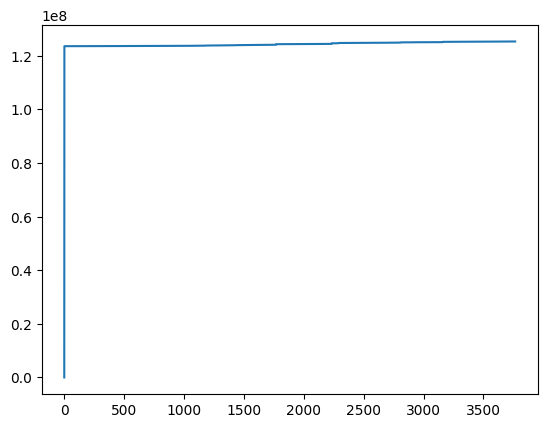

In [3]:
aux=[]
aux_miles=[]
x_axis=[]
unit_odometer=pd.DataFrame()
cont=0

for i in range (0,unit.shape[0]):
    l=len(unit.iloc[i,2])
    #print('Len=',l)
    if l<180:
        aux.append(int(unit.iloc[i,2][68:76],16))
        aux_miles.append((int(unit.iloc[i,2][68:76],16))*0.000621371)
        cont=cont+1     

unit_odometer['Odometer in']=aux
unit_odometer['Odometer en miles']=aux_miles

for i in range(0,cont):
    x_axis.append(i)

unit_odometer
plt.plot(x_axis,aux)

Event codes only for No User messages.
Harsh Turn: 35 on Hex, 53 on Dec

In [4]:
event_code=[]

for i in range(0,unit.shape[0]):
    event_code.append(unit.iloc[i,2][64:68])
    if unit.iloc[i,2][64:66]=='35': # Put the Even Code to look for.
        print(unit.iloc[i,2][64:66],' -> ',unit.iloc[i,0])

35  ->  2026-02-14 19:06:05.669
35  ->  2026-02-16 16:42:44.497
35  ->  2026-02-16 19:26:02.674
35  ->  2026-02-21 18:02:57.975


Satellite number

In [5]:
cont=0
for i in range(0,unit.shape[0]):
    l=len(unit.iloc[i,2])
    if l>92:
        sn=int(unit.iloc[i,2][82:84],16)        
        if sn<5:
            print(unit.iloc[i,0], ' -> ',sn)
            cont=cont+1
    if l<93:
        sn=int(unit.iloc[i,2][55:57],16)        
        if sn<5:
            print(unit.iloc[i,0], ' -> ',sn)
            cont=cont+1

print('Messages with satellite number < 5: ',cont)
        

2026-02-01 00:01:50.958  ->  2
2026-02-01 00:02:30.954  ->  2
2026-02-01 00:03:10.693  ->  2
2026-02-01 00:03:50.541  ->  2
2026-02-01 00:04:30.372  ->  2
2026-02-01 00:05:10.320  ->  2
2026-02-01 00:05:50.160  ->  2
2026-02-01 00:06:29.986  ->  2
2026-02-01 00:07:09.891  ->  2
2026-02-01 00:07:49.757  ->  2
2026-02-01 00:08:29.570  ->  2
2026-02-01 00:09:09.518  ->  2
2026-02-01 00:09:49.373  ->  2
2026-02-01 00:10:29.169  ->  2
2026-02-01 00:11:09.104  ->  2
2026-02-01 00:11:48.956  ->  2
2026-02-01 00:12:28.798  ->  2
2026-02-01 00:13:08.718  ->  2
2026-02-01 00:13:48.573  ->  2
2026-02-01 00:14:28.476  ->  2
2026-02-01 00:15:10.387  ->  2
2026-02-01 00:15:48.158  ->  2
2026-02-01 00:16:28.079  ->  2
2026-02-01 00:17:07.915  ->  2
2026-02-01 00:17:47.734  ->  2
2026-02-01 00:18:27.649  ->  2
2026-02-01 00:19:07.489  ->  2
2026-02-01 00:20:01.602  ->  2
2026-02-01 00:20:02.139  ->  2
2026-02-01 00:20:27.283  ->  2
2026-02-01 00:21:07.091  ->  2
2026-02-01 00:21:46.957  ->  2
2026-02-

Binary inputs

In [6]:
for i in range(0,unit.shape[0]):   
    if unit.iloc[i,2][64:66]=='0C': # Put the Even Code to look for.
        cont=cont+1
        print(bin(int(unit.iloc[i,2][62:64],16)),' -> ',unit.iloc[i,0])
print("Total event codes 0C input2 Off: ",cont)

0b10  ->  2026-02-01 00:00:31.254
0b10  ->  2026-02-14 19:12:45.334
0b10  ->  2026-02-20 18:16:02.210
Total event codes 0C input2 Off:  48216


In [9]:
sequence=[]
sequence.append(unit.iloc[0,2][24:28])
sequence

['0EF0']